# Level 3 - Task 1: Predictive Modeling

## Objective

Build regression models to predict the `Aggregate rating` of restaurants
using relevant features from the Zomato dataset.

### Models
- Linear Regression
- Decision Tree Regression
- Random Forest Regression

### Evaluation Metrics
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../Outputs/feature_engineered_zomato.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 27)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Aggregate rating,Rating color,Rating text,Votes,Restaurant Name Length,Address Length,Has Table Booking Encoded,Has Online Delivery Encoded,Price Range Category,Log Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,4.8,Dark Green,Excellent,314,16,71,1,0,High,5.752573
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,4.5,Dark Green,Excellent,591,16,67,1,0,High,6.383507
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,4.4,Green,Very Good,270,22,56,1,0,Very High,5.602119
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,4.9,Dark Green,Excellent,365,4,70,0,0,Very High,5.902633
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,4.8,Dark Green,Excellent,229,11,64,1,0,Very High,5.438079


In [3]:
target = "Aggregate rating"

if target not in df.columns:
    print(f"Error: '{target}' column not found.")
else:
    print(f"Target column '{target}' is available.")
    print("\nTarget statistics:")
    print(df[target].describe())

Target column 'Aggregate rating' is available.

Target statistics:
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


In [4]:
print("Numerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

Numerical Columns:
['Restaurant ID', 'Country Code', 'Longitude', 'Latitude', 'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes', 'Restaurant Name Length', 'Address Length', 'Has Table Booking Encoded', 'Has Online Delivery Encoded', 'Log Votes']


In [5]:
print("Missing values in numerical columns:")

numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.isnull().sum())

Missing values in numerical columns:
Restaurant ID                  0
Country Code                   0
Longitude                      0
Latitude                       0
Average Cost for two           0
Price range                    0
Aggregate rating               0
Votes                          0
Restaurant Name Length         0
Address Length                 0
Has Table Booking Encoded      0
Has Online Delivery Encoded    0
Log Votes                      0
dtype: int64


In [6]:
# Select features for predicting Aggregate rating

features = [
    "Votes",
    "Price range",
    "Has Table Booking Encoded",
    "Has Online Delivery Encoded",
    "Restaurant Name Length",
    "Address Length",
    "Log Votes"
]

# Keep only features that exist in the dataset
available_features = [
    column for column in features
    if column in df.columns
]

print("Selected Features:")
print(available_features)

Selected Features:
['Votes', 'Price range', 'Has Table Booking Encoded', 'Has Online Delivery Encoded', 'Restaurant Name Length', 'Address Length', 'Log Votes']


 # Prepare X and y

In [7]:
X = df[available_features].copy()
y = df["Aggregate rating"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature matrix shape: (9551, 7)
Target shape: (9551,)

Features:
   Votes  Price range  Has Table Booking Encoded  Has Online Delivery Encoded  \
0    314            3                          1                            0   
1    591            3                          1                            0   
2    270            4                          1                            0   
3    365            4                          0                            0   
4    229            4                          1                            0   

   Restaurant Name Length  Address Length  Log Votes  
0                      16              71   5.752573  
1                      16              67   6.383507  
2                      22              56   5.602119  
3                       4              70   5.902633  
4                      11              64   5.438079  

Target:
0    4.8
1    4.5
2    4.4
3    4.9
4    4.8
Name: Aggregate rating, dtype: float64


# Handle missing/infinite values

In [8]:
# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing numerical values with the median
X = X.fillna(X.median())

# Remove rows where target is missing
valid_rows = y.notna()

X = X.loc[valid_rows]
y = y.loc[valid_rows]

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

print("\nRemaining missing values:")
print(X.isnull().sum())

Final X shape: (9551, 7)
Final y shape: (9551,)

Remaining missing values:
Votes                          0
Price range                    0
Has Table Booking Encoded      0
Has Online Delivery Encoded    0
Restaurant Name Length         0
Address Length                 0
Log Votes                      0
dtype: int64


# Split the dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 7640
Testing samples: 1911


# Linear Regression

In [11]:
# Linear Regression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


# Decision Tree Regression

In [12]:
# Decision Tree Regression

decision_tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

print("Decision Tree Regression trained successfully.")

Decision Tree Regression trained successfully.


# Random Forest Regression

In [13]:
# Random Forest Regression

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest Regression trained successfully.")

Random Forest Regression trained successfully.


# Verify Predictions

In [14]:
print("Sample Predictions")
print("=" * 50)

comparison = pd.DataFrame({
    "Actual Rating": y_test.values[:10],
    "Linear Regression": linear_predictions[:10],
    "Decision Tree": decision_tree_predictions[:10],
    "Random Forest": random_forest_predictions[:10]
})

print(comparison)

Sample Predictions
   Actual Rating  Linear Regression  Decision Tree  Random Forest
0            2.1           3.271923       3.409434       3.237440
1            4.1           3.498711       3.159524       3.197337
2            3.2           3.029798       3.164452       3.197768
3            4.4           3.876573       3.444444       3.404419
4            3.5           2.348976       3.045977       3.074315
5            0.0           0.362536       0.000000       0.000000
6            3.2           2.708431       3.164452       3.149788
7            0.0           0.887886       0.000000       0.000000
8            3.6           3.086014       3.197521       3.239294
9            4.0           2.709532       3.164452       3.103799


# Calculate Evaluation Metrics

In [15]:
def evaluate_model(model_name, actual, predictions):
    mae = mean_absolute_error(actual, predictions)
    mse = mean_squared_error(actual, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predictions)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }


results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Decision Tree Regression",
        y_test,
        decision_tree_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest Regression",
        y_test,
        random_forest_predictions
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.613523,0.550300,0.741822,0.758228
1,Decision Tree Regression,0.237486,0.133854,0.365861,0.941192
2,Random Forest Regression,0.222518,0.115353,0.339637,0.949320


# Display a Rounded Results Table

In [16]:
results_rounded = results_df.copy()

results_rounded[
    ["MAE", "MSE", "RMSE", "R2 Score"]
] = results_rounded[
    ["MAE", "MSE", "RMSE", "R2 Score"]
].round(4)

print("Model Performance Comparison")
print("=" * 70)

results_rounded

Model Performance Comparison


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.6135,0.5503,0.7418,0.7582
1,Decision Tree Regression,0.2375,0.1339,0.3659,0.9412
2,Random Forest Regression,0.2225,0.1154,0.3396,0.9493


# Identify the Best Model

In [17]:
best_model = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print("Best Performing Model:")
print(best_model["Model"])

print("\nR2 Score:", round(best_model["R2 Score"], 4))
print("RMSE:", round(best_model["RMSE"], 4))

Best Performing Model:
Random Forest Regression

R2 Score: 0.9493
RMSE: 0.3396


# Results

In [18]:
output_path = "../Outputs/model_performance_comparison.csv"

results_rounded.to_csv(
    output_path,
    index=False
)

print(f"Model performance saved to: {output_path}")

Model performance saved to: ../Outputs/model_performance_comparison.csv


# Model Performance Visualization

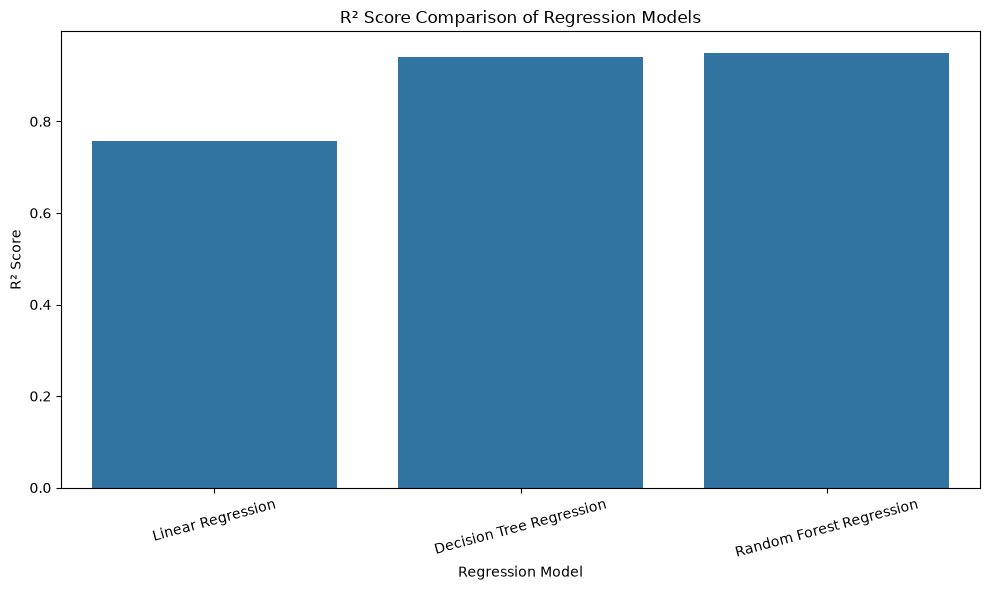

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_rounded,
    x="Model",
    y="R2 Score"
)

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# RMSE Comparison

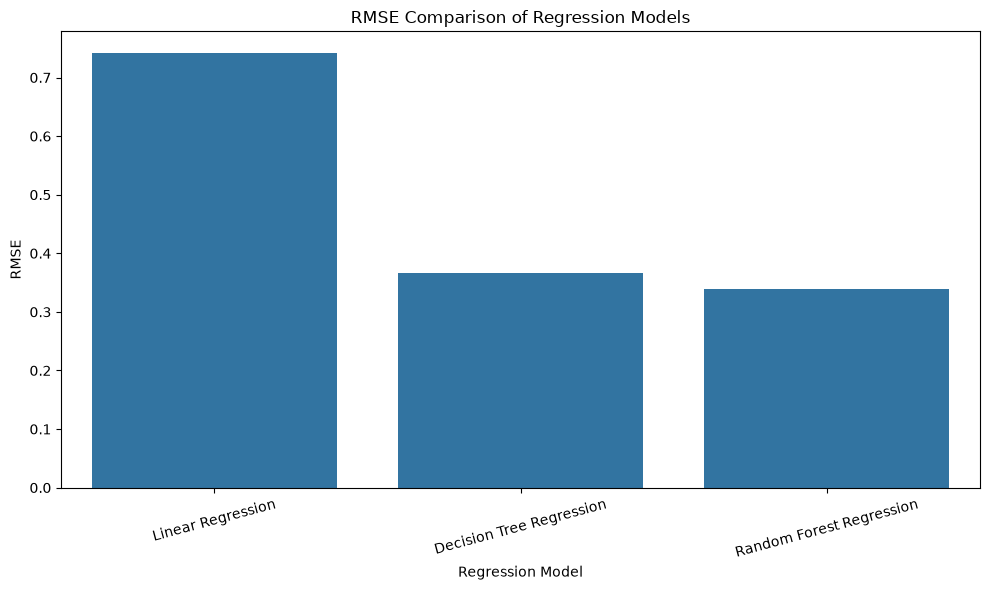

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_rounded,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Random Forest Feature Importance

In [21]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
feature_importance

Random Forest Feature Importance:


,Feature,Importance
6,Log Votes,0.498104
0,Votes,0.481815
5,Address Length,0.006397
4,Restaurant Name Length,0.004704
1,Price range,0.004038
3,Has Online Delivery Encoded,0.003110
2,Has Table Booking Encoded,0.001832


# Feature Importance Visualization

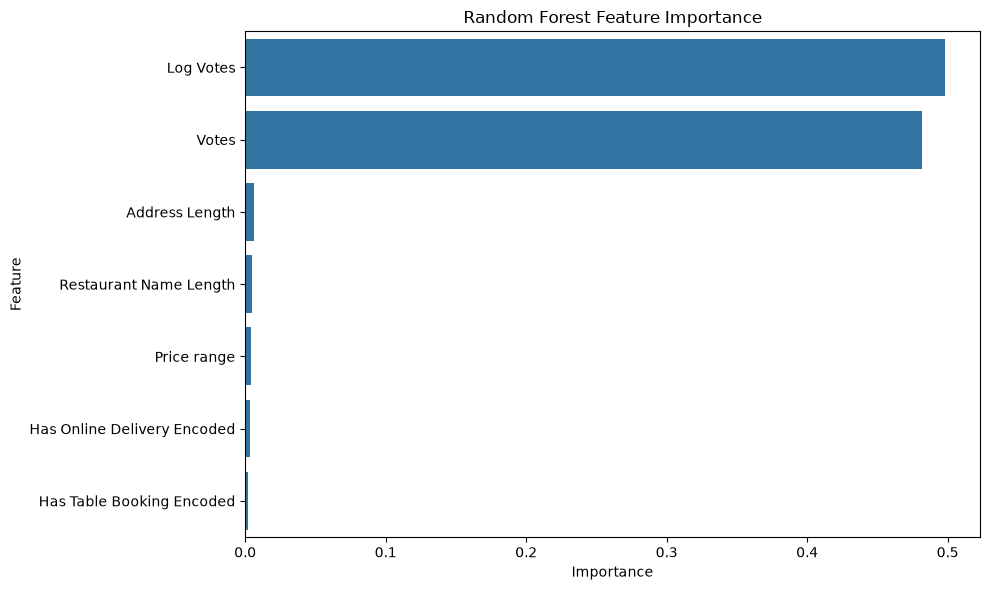

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Save Feature Importance

In [23]:
feature_importance.to_csv(
    "../Outputs/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


# Prediction Visualization

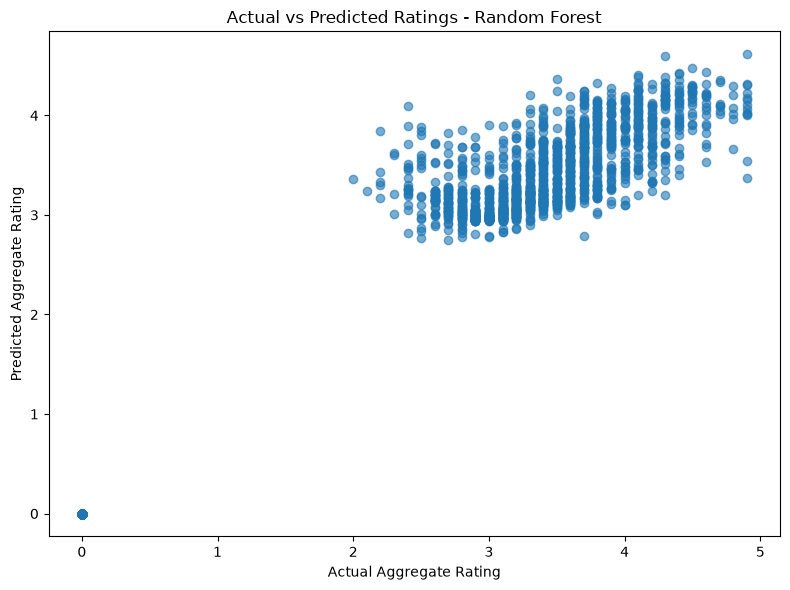

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.6
)

plt.xlabel("Actual Aggregate Rating")
plt.ylabel("Predicted Aggregate Rating")
plt.title("Actual vs Predicted Ratings - Random Forest")

plt.tight_layout()
plt.show()

# Conclusion

Predictive modeling was successfully performed to estimate the Aggregate
rating of restaurants using relevant features from the Zomato dataset.

Three regression models were implemented and evaluated:

- Linear Regression
- Decision Tree Regression
- Random Forest Regression

The models were compared using Mean Absolute Error (MAE), Mean Squared Error
(MSE), Root Mean Squared Error (RMSE), and R² Score.

The model with the highest R² Score and comparatively lower error metrics was
identified as the best-performing model for this dataset.

Random Forest feature importance was also analyzed to identify the features
that contributed most to the prediction of restaurant ratings.

The model performance results and feature importance results were saved as
CSV files for further analysis.